# Name: Baraka Mandi

# Question 4: CNN Feature Extraction with Filters and Pooling

**Task 1:** Edge detection with Sobel filters (NumPy + OpenCV)  
**Task 2:** Max Pooling and Average Pooling (PyTorch)

In [ ]:
# Install dependencies if needed
# !pip install numpy opencv-python matplotlib torch

---
## Task 1: Edge Detection Using Convolution (Sobel Filter)

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

### Step 1: Load a grayscale image
Set `IMAGE_PATH` to any image on your machine. If the file isn't found, a sample image is downloaded; if that also fails (e.g. no internet), a synthetic test image with geometric shapes is generated so the notebook always runs.

In [5]:
IMAGE_PATH = "bently.jpg"   # <--image path

def load_grayscale_image(path):
    # 1) Try the local file
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            print(f"Loaded local image: {path}")
            return img

    # 2) Try downloading a standard sample image (OpenCV's 'building' test image)
    try:
        import urllib.request
        url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/building.jpg"
        urllib.request.urlretrieve(url, path)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            print(f"Downloaded sample image from {url}")
            return img
    except Exception as e:
        print("Download failed:", e)

    # 3) Fallback: create a synthetic grayscale image with clear edges
    print("Using a synthetic test image.")
    img = np.zeros((256, 256), dtype=np.uint8)
    cv2.rectangle(img, (30, 30), (120, 120), 255, -1)       # filled square
    cv2.circle(img, (180, 80), 45, 180, -1)                  # filled circle
    pts = np.array([[60, 230], [128, 150], [200, 230]], np.int32)
    cv2.fillPoly(img, [pts], 120)                            # filled triangle
    return img

image = load_grayscale_image(IMAGE_PATH)
print("Image shape:", image.shape, "| dtype:", image.dtype)

Loaded local image: bently.jpg
Image shape: (677, 1200) | dtype: uint8


### Step 2: Define the Sobel filters

$$\text{Sobel X} = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \qquad \text{Sobel Y} = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

Sobel X responds to **vertical edges** (intensity changes along x); Sobel Y responds to **horizontal edges** (changes along y).

In [6]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

print("Sobel X:\n", sobel_x)
print("\nSobel Y:\n", sobel_y)

Sobel X:
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Sobel Y:
 [[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


### Step 3: Apply the filters with convolution

In [7]:
# Convert to float for precise computation
img_float = image.astype(np.float64)

# Convolve the image with each Sobel kernel
edges_x = cv2.filter2D(img_float, cv2.CV_64F, sobel_x)
edges_y = cv2.filter2D(img_float, cv2.CV_64F, sobel_y)

# Take magnitude of response and convert to uint8 for display
edges_x_disp = cv2.convertScaleAbs(edges_x)
edges_y_disp = cv2.convertScaleAbs(edges_y)

print("Sobel X response range:", edges_x.min(), "to", edges_x.max())
print("Sobel Y response range:", edges_y.min(), "to", edges_y.max())

Sobel X response range: -911.0 to 861.0
Sobel Y response range: -943.0 to 973.0


### Step 4: Display the original and filtered images

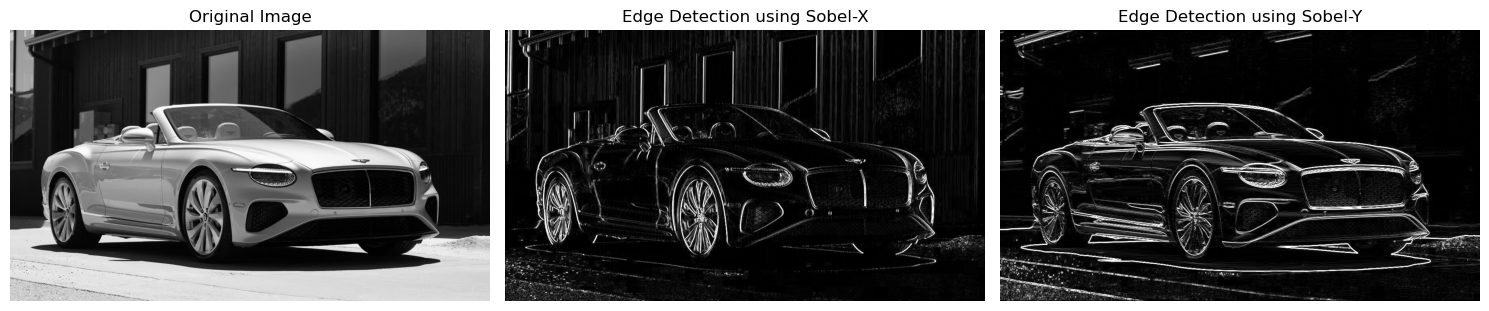

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")

axes[1].imshow(edges_x_disp, cmap="gray")
axes[1].set_title("Edge Detection using Sobel-X")

axes[2].imshow(edges_y_disp, cmap="gray")
axes[2].set_title("Edge Detection using Sobel-Y")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Observation:** The Sobel-X output highlights vertical edges (left/right boundaries of objects), while the Sobel-Y output highlights horizontal edges (top/bottom boundaries).

---
## Task 2: Max Pooling and Average Pooling (PyTorch)

In [9]:
import torch
import torch.nn as nn

torch.manual_seed(42)   # for reproducible results

### Step 1: Create a random 4×4 input matrix

In [11]:
# Random 4x4 "image" with integer values 0-9
input_matrix = torch.randint(0, 10, (4, 4)).float()

# Add batch and channel dimensions -> shape (1, 1, 4, 4)
input_tensor = input_matrix.unsqueeze(0).unsqueeze(0)
print("Input tensor shape:", input_tensor.shape)

Input tensor shape: torch.Size([1, 1, 4, 4])


### Step 2: Apply 2×2 Max Pooling and 2×2 Average Pooling


In [12]:
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

max_pooled = max_pool(input_tensor)
avg_pooled = avg_pool(input_tensor)

### Step 3: Print the results

In [13]:
print("Original 4x4 Matrix:")
print(input_matrix)

print("\nMax Pooled Matrix (2x2):")
print(max_pooled.squeeze())

print("\nAverage Pooled Matrix (2x2):")
print(avg_pooled.squeeze())

Original 4x4 Matrix:
tensor([[5., 5., 7., 6.],
        [9., 6., 3., 1.],
        [9., 3., 1., 9.],
        [7., 9., 2., 0.]])

Max Pooled Matrix (2x2):
tensor([[9., 7.],
        [9., 9.]])

Average Pooled Matrix (2x2):
tensor([[6.2500, 4.2500],
        [7.0000, 3.0000]])
